<a href="https://colab.research.google.com/github/siddhartha-alexander/Real-Time-Credit-Card-Fraud-Detection-System/blob/main/Real_Time_Credit_Card_Fraud_Detection_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Required Libraries**

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from scipy.stats import randint
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import *
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.metrics import roc_auc_score

**Objective**

The goal of this project is to build a machine learning model to detect fraudulent credit card transactions from highly imbalanced transaction data. The focus is on maximizing fraud detection (recall) while managing false positives, which is critical in real-world financial systems.

**Description**
- The dataset contains anonymized credit card transactions.
- Features V1–V28 are PCA-transformed components to preserve user privacy.
- `Amount` represents the transaction amount.
- `Class` is the target variable:
  - 0 → Legitimate transaction
  - 1 → Fraudulent transaction


**Class Imbalance**
The dataset is highly imbalanced, with fraud transactions accounting for approximately 0.20% of the total data. Due to this imbalance, accuracy alone is not a reliable evaluation metric.



In [2]:
!pip install kaggle
from google.colab import files
files.upload()

# Move kaggle.json to correct location
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download the dataset
!kaggle datasets download -d mlg-ulb/creditcardfraud

# Unzip
!unzip creditcardfraud.zip

# Load
import pandas as pd
df = pd.read_csv('creditcard.csv')

# Verify
print(f"Shape: {df.shape}")
assert df.shape[0] == 284807, "Wrong dataset!"
print("✅ Correct dataset loaded!")

Saving creditcard.csv to creditcard.csv
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 10, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/cli.py", line 68, in main
    out = args.func(**command_args)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 1741, in dataset_download_cli
    with self.build_kaggle_client() as kaggle:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 688, in build_kaggle_client
    username=self.config_values['username'],
             ~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
KeyError: 'username'
unzip:  cannot find or open creditcardfraud.zip, creditcardfraud.zip.zip or creditcardfraud.zip.ZIP.
Shape: (284807,

In [3]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
df.isna().sum().sum()

np.int64(0)

In [6]:
df.isna().any().sum()

np.int64(0)

In [7]:
df.duplicated().sum()

np.int64(1081)

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


**Exploratory Data Analysis**

**a.Time Analysis**

In [10]:
#converting time to Hours
df['Hour']=df['Time']//3600
fraudby_hour=df[df['Class']==1].groupby('Hour')['Class'].count()
normalyby_hour=df[df['Class']==0].groupby('Hour')['Class'].count()

In [11]:
fraudby_hour


,Class
Hour,
0.0,2
1.0,2
2.0,21
3.0,13
4.0,6
5.0,11
6.0,3
7.0,23
8.0,5


In [12]:
normalyby_hour

,Class
Hour,
0.0,3929
1.0,2211
2.0,1552
3.0,1805
4.0,1076
5.0,1668
6.0,1819
7.0,3343
8.0,5143


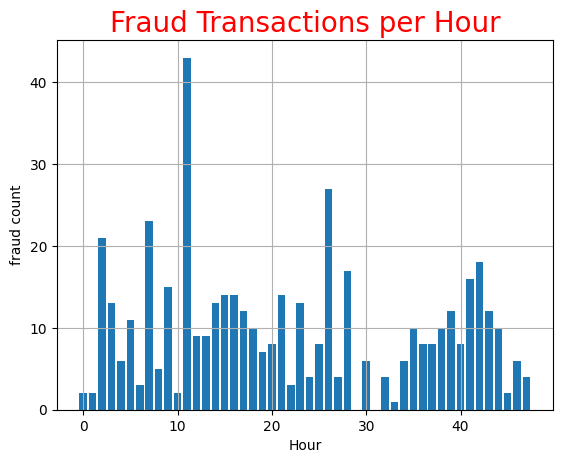

In [13]:
plt.bar(fraudby_hour.index,fraudby_hour.values)
plt.title('Fraud Transactions per Hour',fontsize=20,color='Red')
plt.xlabel('Hour')
plt.ylabel('fraud count')
plt.grid(True)
plt.show()


**Fraud Rate**

In [14]:
combined=pd.DataFrame({
'Fraud':fraudby_hour,
'normal':normalyby_hour
})
combined=combined.fillna(0).astype(int)
combined

,Fraud,normal
Hour,,
0.0,2,3929
1.0,2,2211
2.0,21,1552
3.0,13,1805
4.0,6,1076
5.0,11,1668
6.0,3,1819
7.0,23,3343
8.0,5,5143


In [15]:
combined=combined[combined['Fraud']!=0]
combined

,Fraud,normal
Hour,,
0.0,2,3929
1.0,2,2211
2.0,21,1552
3.0,13,1805
4.0,6,1076
5.0,11,1668
6.0,3,1819
7.0,23,3343
8.0,5,5143


In [16]:
Total=combined['Fraud']+combined['normal']
fraud_rate=(combined['Fraud']/Total)*100
fraud_rate

,0
Hour,
0.0,0.050878
1.0,0.090375
2.0,1.335029
3.0,0.715072
4.0,0.554529
5.0,0.655152
6.0,0.164654
7.0,0.683304
8.0,0.097125


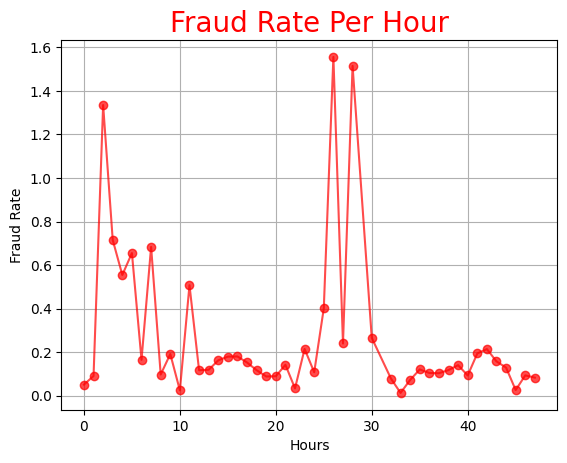

In [17]:
plt.plot(fraud_rate.index,fraud_rate.values,marker='o',color='red',alpha=0.7)
plt.title('Fraud Rate Per Hour',fontsize=20,color='red')
plt.xlabel('Hours')
plt.ylabel('Fraud Rate')
plt.grid(True)
plt.show()

**b.Amount Analyis**

In [18]:
df['Amount']

,Amount
0,149.62
1,2.69
2,378.66
3,123.50
4,69.99
...,...
284802,0.77
284803,24.79
284804,67.88
284805,10.00


In [19]:
frauded_amount =df[df['Class'] == 1].groupby('Hour')['Amount'].sum()
frauded_amount

,Amount
Hour,
0.0,529.00
1.0,298.93
2.0,1829.78
3.0,220.05
4.0,790.26
5.0,1416.67
6.0,104.11
7.0,2757.78
8.0,137.15


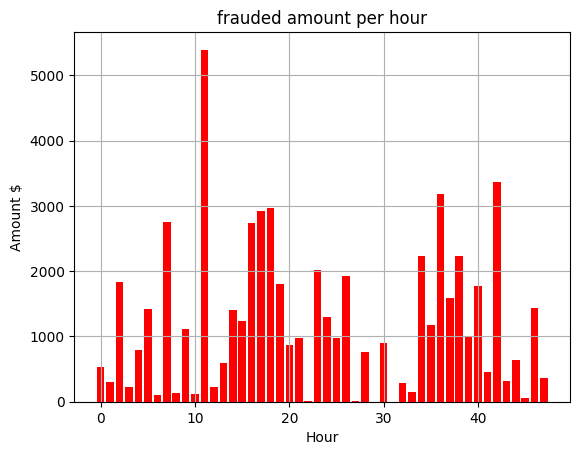

In [20]:
plt.bar(frauded_amount.index,frauded_amount.values,color='red')
plt.title('frauded amount per hour')
plt.xlabel('Hour')
plt.ylabel('Amount $')
plt.grid(True)
plt.show()

**Splitting Data**

In [21]:
X=df.drop(columns='Class')
y=df['Class']
x_train,x_test,y_train,y_test=train_test_split(X,y,random_state=45,test_size=0.2)

**Checking Data Imbalance**

In [22]:
df['Class'].value_counts()

,count
Class,
0,283253
1,473


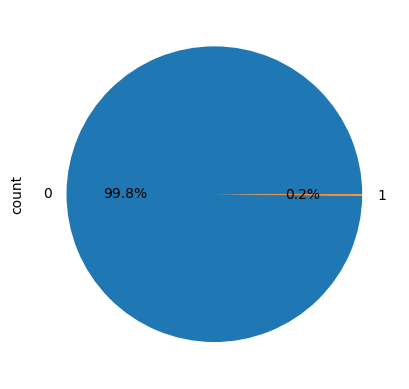

In [23]:
class_counts=df['Class'].value_counts()
class_counts.plot.pie(autopct='%1.1f%%')
plt.show()

**SMOTE and Standardization**

In [24]:
smote=SMOTE(random_state=45)
x_train_balanced,y_train_balanced=smote.fit_resample(x_train,y_train)
sc=StandardScaler()
x_train_scaled=sc.fit_transform(x_train_balanced)
x_test_scaled=sc.transform(x_test)

**Problem Challenges**

- Extreme class imbalance makes accuracy misleading.
- False negatives (missed frauds) are more costly than false positives.
- The model must prioritize recall while maintaining reasonable precision.

**Evaluation Metrics**
- Precision
- Recall
- F1-score
- Precision–Recall trade-off

Accuracy is not emphasized due to imbalance.


**Model Training**

Baseline Model

A baseline model was trained to establish initial performance and highlight the impact of class imbalance. This helps evaluate improvements from advanced models.


**a.Logistic Regresion**

In [25]:
lr=LogisticRegression()
lr.fit(x_train_scaled,y_train_balanced)

LogisticRegression()

In [26]:
y_pred=lr.predict(x_test_scaled)
print(accuracy_score(y_test,y_pred)*100)

99.1453142071688


In [27]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56665
           1       0.13      0.84      0.22        81

    accuracy                           0.99     56746
   macro avg       0.56      0.92      0.61     56746
weighted avg       1.00      0.99      0.99     56746



**Adjusting Thresholds**

In [28]:
y_probs=lr.predict_proba(x_test_scaled)[:,1]
y_probs

array([4.56779985e-02, 5.82658164e-06, 2.93182693e-05, ...,
       3.48629883e-05, 5.69987926e-02, 2.62223588e-03])

In [29]:
thresholds=[0.3,0.4,0.5,0.6,0.7,0.8]
for t in thresholds:
  y_pred_threshold=(y_probs>=t).astype(int)
  f1=f1_score(y_test,y_pred_threshold,pos_label=1)
  precision=precision_score(y_test,y_pred_threshold,pos_label=1)
  recall=recall_score(y_test,y_pred_threshold,pos_label=1)
  print(f"threshold:{t} f1score:{f1} precision:{precision} recall:{recall}")

threshold:0.3 f1score:0.12522686025408347 precision:0.06758080313418217 recall:0.8518518518518519
threshold:0.4 f1score:0.1684981684981685 precision:0.09349593495934959 recall:0.8518518518518519
threshold:0.5 f1score:0.21900161030595813 precision:0.1259259259259259 recall:0.8395061728395061
threshold:0.6 f1score:0.26171875 precision:0.1554524361948956 recall:0.8271604938271605
threshold:0.7 f1score:0.2857142857142857 precision:0.17438692098092642 recall:0.7901234567901234
threshold:0.8 f1score:0.35492957746478876 precision:0.22992700729927007 recall:0.7777777777777778


In [73]:
threshold=0.8
y_pred_custom=(y_probs>=threshold).astype(int)
lr_precision = precision_score(y_test, y_pred_custom)
lr_recall = recall_score(y_test, y_pred_custom)
lr_f1 = f1_score(y_test, y_pred_custom)
print(f"Threshold: {threshold:.1f}")
print(f"Precision: {lr_precision:.2f}")
print(f"Recall: {lr_recall:.2f}")
print(f"F1-score: {lr_f1:.2f}")

Threshold: 0.8
Precision: 0.80
Recall: 0.73
F1-score: 0.76


**b.Random Forest Model**

Random Forest was selected due to its robustness, ability to handle non-linear relationships, and resistance to overfitting. Class imbalance was addressed using class weighting.


In [31]:
rf=RandomForestClassifier(random_state=45,warm_start=False)

In [36]:
param_distributions = {
    'n_estimators': [100,150],
    'max_depth': [10, 15],
    'min_samples_split': [10, 15],
    'min_samples_leaf': [2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced', 'balanced_subsample', None]
}

In [37]:
rf_random = RandomizedSearchCV(estimator=rf,param_distributions=param_distributions,n_iter=8, cv=3,  scoring='f1', n_jobs=-1,verbose=2)


In [38]:
rf_random.fit(x_train_scaled, y_train_balanced)
print(rf_random.best_params_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
{'n_estimators': 150, 'min_samples_split': 15, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 15, 'class_weight': 'balanced_subsample'}


In [40]:
rf_final=RandomForestClassifier(**rf_random.best_params_)

In [41]:
rf_final.fit(x_train_scaled,y_train_balanced)


RandomForestClassifier(class_weight='balanced_subsample', max_depth=15,
                       max_features='log2', min_samples_leaf=4,
                       min_samples_split=15, n_estimators=150)

In [42]:
y_pref=rf_final.predict(x_test_scaled)

In [43]:
print(accuracy_score(y_test,y_pred))

0.9914531420716879


In [45]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56665
           1       0.13      0.84      0.22        81

    accuracy                           0.99     56746
   macro avg       0.56      0.92      0.61     56746
weighted avg       1.00      0.99      0.99     56746



In [47]:
y_probs=rf_final.predict_proba(x_test_scaled)[:,1]
y_probs

array([0.00149031, 0.00025815, 0.00122142, ..., 0.00062182, 0.00878344,
       0.00465821])

In [51]:
thresholds=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8]
for t in thresholds:
  y_pred_threshold=(y_probs>=t).astype(int)
  f1=f1_score(y_test,y_pred_threshold,pos_label=1)
  recall=recall_score(y_test,y_pred_threshold,pos_label=1)
  precision=precision_score(y_test,y_pred_threshold,pos_label=1)
  print(f'threshold{t} f1_score{f1} precision{precision} recall{recall}')

threshold0.1 f1_score0.21495327102803738 precision0.12299465240641712 recall0.8518518518518519
threshold0.2 f1_score0.43537414965986393 precision0.3004694835680751 recall0.7901234567901234
threshold0.3 f1_score0.6078431372549019 precision0.5040650406504065 recall0.7654320987654321
threshold0.4 f1_score0.6815642458100558 precision0.6224489795918368 recall0.7530864197530864
threshold0.5 f1_score0.7142857142857143 precision0.6896551724137931 recall0.7407407407407407
threshold0.6 f1_score0.7239263803680982 precision0.7195121951219512 recall0.7283950617283951
threshold0.7 f1_score0.7468354430379747 precision0.7662337662337663 recall0.7283950617283951
threshold0.8 f1_score0.7612903225806451 precision0.7972972972972973 recall0.7283950617283951


In [74]:
threshold=0.8
y_pred_custom=(y_probs>=threshold).astype(int)
rf_f1_val = f1_score(y_test, y_pred_custom)
rf_recall_val = recall_score(y_test, y_pred_custom)
rf_precision_val = precision_score(y_test, y_pred_custom)
print(f'f1_score: {rf_f1_val:.2f}')
print(f'recall: {rf_recall_val:.2f}')
print(f'precision: {rf_precision_val:.2f}')

f1_score: 0.76
recall: 0.73
precision: 0.80


**c.XGBoost Model**

XGBoost was implemented as an advanced gradient boosting approach to improve performance on imbalanced data. Scale_pos_weight was used to address class imbalance effectively.


In [68]:
XGB=XGBClassifier(n_estimators=100,random_state=42,max_depth=6,learning_rate=0.1)
XGB.fit(x_train_scaled,y_train_balanced)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [69]:
y_pred=XGB.predict(x_test_scaled)

In [70]:
print(accuracy_score(y_test,y_pred))

0.9989955239135798


In [75]:
xgb_precision=precision_score(y_test,y_pred)
xgb_recall=recall_score(y_test,y_pred)
xgb_f1=f1_score(y_test,y_pred)

In [71]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56665
           1       0.62      0.78      0.69        81

    accuracy                           1.00     56746
   macro avg       0.81      0.89      0.84     56746
weighted avg       1.00      1.00      1.00     56746



In [77]:
final_report=pd.DataFrame({
    'Models':['Logistic Regression','Random Forest','XGBoost'],
    'Precison':[lr_precision,rf_precision_val,xgb_precision],
    'Recall':[lr_recall,rf_recall_val,xgb_recall],
    'F1 Score':[lr_f1,rf_f1_val,xgb_f1]

})
final_report

,Models,Precison,Recall,F1 Score
0,Logistic Regression,0.797297,0.728395,0.761290
1,Random Forest,0.797297,0.728395,0.761290
2,XGBoost,0.617647,0.777778,0.688525


**Business Impact**

- High fraud recall reduces financial loss by minimizing undetected fraudulent transactions.
- False positives can be reviewed through secondary verification systems.
- The model demonstrates how machine learning can support real-time fraud monitoring in financial systems.


**Conclusion**

After comparing Logistic Regression, Random Forest, and XGBoost, Logistic Regression and Random Forest showed the best overall balance between precision and recall, as reflected by their higher F1-scores. However, XGBoost was able to detect a larger number of fraudulent transactions, achieving the highest recall among all models.

In a real-world credit card fraud scenario, missing a fraud transaction is more costly than flagging a legitimate one by mistake. False positives can be reviewed through additional verification steps, but false negatives directly lead to financial loss. Because of this, recall was treated as the most important metric for model selection.

Even though XGBoost had a slightly lower precision and F1-score, it was chosen as the final model because it was more effective at identifying fraud cases. This choice reflects a practical, business-oriented approach rather than relying only on overall accuracy or a single evaluation metric.
